In [1]:
# Installs
!pip install requests
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install tqdm

In [2]:
# Imports/Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
# Loading TMDB API Key
import os
from dotenv import load_dotenv

load_dotenv()
TMDB_API_KEY = os.getenv("TMDB_API_KEY")
print(TMDB_API_KEY)

None


In [4]:
# First API Test (If [200], API Call was successful)
url = f"https://api.themoviedb.org/3/discover/movie?api_key=56d74cf46936c9b4d1c664fb170584eb&page=1"
response = requests.get(url)
response

<Response [200]>

## 1. Defining the Problem
The main focus is to evaluate the reactions of the audience and find patterns across multiple movie genres using data from the TMDB API.

Furthermore, I want to look into one important question that I want to answer from this data: 
**How does a movie's runtime correlate with its audience rating and how does this relationship remain consistent across different genres**

Why is this question relevent? Well, this type of data can be really improtant for film studios, producers, and streaming platforms looking to optimize production budgets and find their ideal length of a film based on what movie genre they want to make to maxmize audience satisfaction.

In [5]:
#Look @ JSON
response.json()["results"][:5]

[{'adult': False,
  'backdrop_path': '/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg',
  'genre_ids': [878, 28, 12],
  'id': 969681,
  'title': 'Spider-Man: Brand New Day',
  'original_language': 'en',
  'original_title': 'Spider-Man: Brand New Day',
  'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.",
  'popularity': 756.7679,
  'poster_path': '/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg',
  'release_date': '2026-07-29',
  'softcore': False,
  'video': False,
  'vote_average': 7.844,
  'vote_count': 2637},
 {'adult': False,
  'backdrop_path': '/l9mFW9HQnAZ4r1ChZJHoOT3jaal.jpg',
  'genre_ids': [35, 12, 10751],
  'id': 1204680,
  'title': 'Coyote vs. Acme',
  'original_language': 'e

## 2. Data Description
This project relies on data extracted directly from The Movie Database (TMDB API). The unit of analysis is individual feature films.

**Key Variables Coceptualized and Operationalized**
* **Genre:** The category or style of the movie, measured by mapping TMDB's 'genre_ids' to their official string names via the TMDB Genre List API.
* **Audience Rating:** Audience enjoyment, measured by the 'vote_average' score (0-10).
* **Runtime:** The length of the movie, measured in minutes via the TMDB Movie Details API.
* **Vote Count:** The total number of audience members who rated the film, measured by the 'vote_count' field.

**Academic Context & References:**
1. Souza, T. L. D., Nishijima, M., & Fava, A. C. P. (2019). Do consumer and expert reviews affect the length of time a film is kept on screens in the USA? *Journal of Cultural Economics*, 43(1), 145-171.
2. McKenzie, J. (2023). The economics of movies (revisited): A survey of recent literature. *Journal of Economic Surveys*, 37(2), 480-525.
3. Sikdar, S., Kang, U., & O'Donovan, J. (2015). Statistical patterns in movie rating behavior. *PLOS ONE*, 10(8).

In [6]:
# 1. Get Genre Mapping Dictionary
genre_url = f"https://api.themoviedb.org/3/genre/movie/list?api_key=56d74cf46936c9b4d1c664fb170584eb"
genres_data = requests.get(genre_url).json().get('genres', [])
genre_map = {g['id']: g['name'] for g in genres_data}

movies_data = []

In [7]:
# 2. Get movies from Discover API (Limiting to 10 pgs for a solid sample size)
print("Getting movie list...")
for page in tqdm(range(1, 11)):
    discover_url = f"https://api.themoviedb.org/3/discover/movie?api_key=56d74cf46936c9b4d1c664fb170584eb&page=2"
    results = requests.get(discover_url).json().get('results', [])

for movie in results:
        # Extract primary genre (first ID in the list)
        primary_genre_id = movie['genre_ids'][0] if movie.get('genre_ids') else None

        movies_data.append({
                    'movie_id': movie['id'],
                    'title': movie['title'],
                    'primary_genre': genre_map.get(primary_genre_id, "Unknown"),
                    'vote_average': movie['vote_average'],
                    'vote_count': movie['vote_count'],
                    'popularity': movie['popularity']
            })
df_movies = pd.DataFrame(movies_data)

Getting movie list...


100%|██████████| 10/10 [00:00<00:00, 24.20it/s]


In [8]:
# 3. Get Runtime from Movie Details API
print("Fetching runtimes...")
runtimes = []
for movie_id in tqdm(df_movies['movie_id']):
    details_url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key=56d74cf46936c9b4d1c664fb170584eb"
    details = requests.get(details_url).json()
    runtimes.append(details.get('runtime', pd.NA))

df_movies['runtime'] = runtimes

Fetching runtimes...


100%|██████████| 20/20 [00:01<00:00, 16.64it/s]


In [9]:
# Data Cleaning Steps using Pandas
print(f"Original Dataset Size: {df_movies.shape}")

# 1. Drop rows with missing runtimes or ratings
df_clean = df_movies.dropna(subset=['runtime', 'vote_average'])

# 2. Filter out movies with low vote counts to avoid skewed rating averages
df_clean = df_clean[df_clean['vote_count'] >= 100]

# 3. Filter out movies with 0 runtime (data errors)
df_clean = df_clean[df_clean['runtime'] > 0]

print(f"Cleaned Dataset Size: {df_clean.shape}")
display(df_clean.head())

Original Dataset Size: (20, 7)
Cleaned Dataset Size: (12, 7)


,movie_id,title,primary_genre,vote_average,vote_count,popularity,runtime
4,860508,The Whisper Man,Crime,6.798,631,92.0494,111
5,687163,Project Hail Mary,Science Fiction,8.642,7711,89.6056,157
7,1275779,Disclosure Day,Science Fiction,7.468,3283,91.3835,146
8,980431,Avatar Aang: The Last Airbender,Animation,9.148,1113,91.1521,99
9,1083381,Backrooms,Horror,7.053,3248,86.4387,111


## 3. Data Cleaning and Preparation
To make sure the integrity of the analysis, several cleaning steps were executed using pandas:
1. **Handling Missing Values:** Any rows missing `runtime` or `vote_average` were dropped, as these are the core variables of the research question.
2. **Filtering Vote Counts:** Movies with fewer than 100 votes were removed. This trade-off reduces the overall dataset size but prevents obscure movies with a single 10/10 rating from artificially skewing the runtime-to-rating correlations.
3. **Primary Genre Extraction:** Because films often feature multiple overlapping genres, only the first (primary) `genre_id` was extracted to allow for clean categorical grouping when testing consistency across genres.

/var/folders/sr/mcgs4cjn3rvc0bxlj632h5n80000gn/T/ipykernel_4439/1985723567.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="viridis")


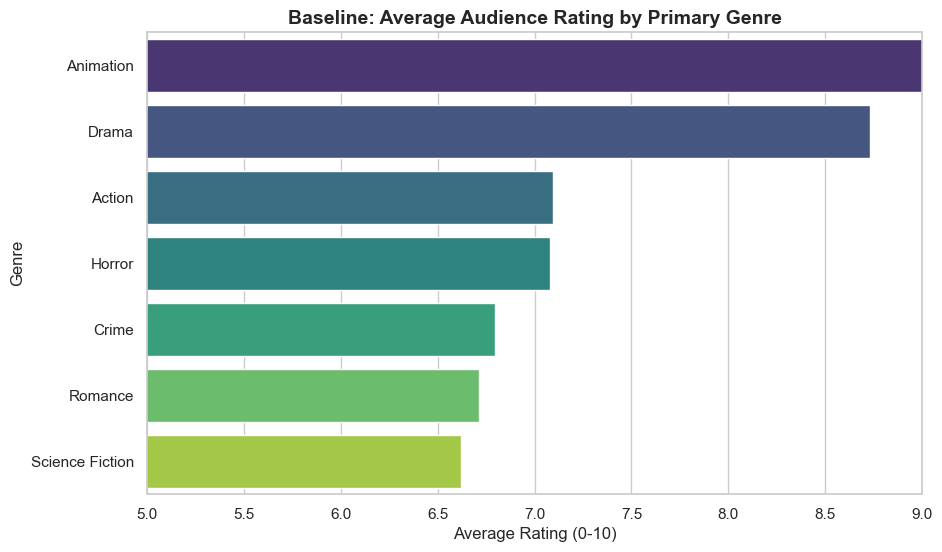

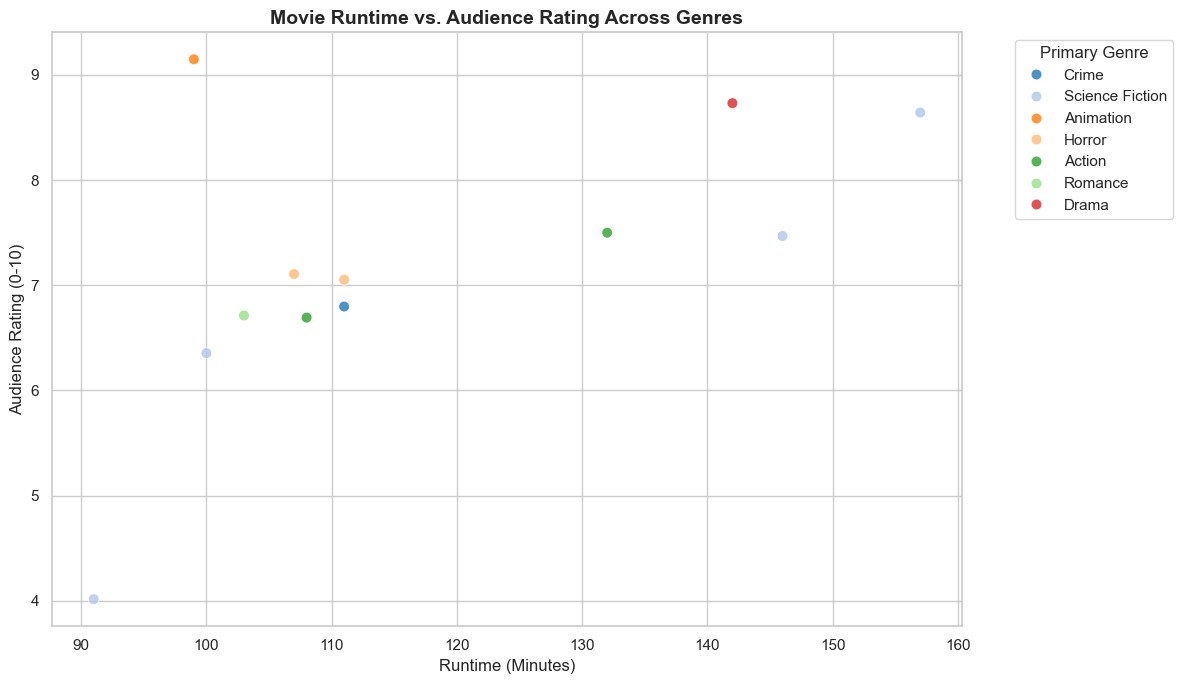

In [10]:
# Set visualization style
sns.set_theme(style="whitegrid")

# Figure 1: Horizontal Bar Chart - Establishing the Genre Baseline
plt.figure(figsize=(10, 6))
genre_ratings = df_clean.groupby('primary_genre')['vote_average'].mean().sort_values(ascending=False)
sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="viridis")
plt.title("Baseline: Average Audience Rating by Primary Genre", fontsize=14, fontweight='bold')
plt.xlabel("Average Rating (0-10)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.xlim(5, 9) 
plt.show()

# Figure 2: Scatter Plot - Runtime vs Rating colored by Genre[cite: 1, 2]
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clean, x='runtime', y='vote_average', hue='primary_genre', palette="tab20", s=60, alpha=0.8)
plt.title("Movie Runtime vs. Audience Rating Across Genres", fontsize=14, fontweight='bold')
plt.xlabel("Runtime (Minutes)", fontsize=12)
plt.ylabel("Audience Rating (0-10)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Primary Genre")
plt.tight_layout()
plt.show()

## 4 & 5. Visualizations, Insights, and Storytelling
To address how runtime impacts audience scores across genres, we must first establish a baseline. The bar chart reveals that audiences inherently rate certain genres (like Drama and Animation) higher on average than others (like Action or Horror).

Building on that baseline, the scatter plot examining runtime versus rating demonstrates how movie length influences these scores. The visualization shows a dense cluster of mid-rated films (6.5 to 7.5) spanning the 100 to 115-minute mark. While a longer runtime does not automatically guarantee a better rating, there is a visible trend: genres typically associated with longer runtimes (such as Drama) maintain their higher rating baseline, whereas genres like Science Fiction show massive variance, swinging from a 4.0 rating at shorter runtimes to an 8.6 at longer runtimes.

## 6. Limitations, Ethics, and Reflection
While TMDB offers a massive repository of data, several limitations exist:
* **Genre Simplification:** Operationalizing a film by only its *primary* genre strips away meaning. A multi-genre film categorized solely by its first tag masks its true appeal and may skew genre-specific correlation results.
* **Demographic Bias:** TMDB ratings are crowd-sourced from its specific user base. These ratings do not represent a true random sample of the global population.
* **Next Steps:** If given more time, I would run regression lines for each specific genre on the scatter plot to see if the correlation strength changes dramatically between categories.

## 7. Code and Transparency
* **GitHub Repository:** [Insert your GitHub URL here]
* **Data Source:** The Movie Database (TMDB) API
* **AI Usage Disclosure:** Generative AI was utilized strictly for reformatting / cocising my words, and for formatting my code + understanding certain elements to make sure they were used properly. All original ideas were made by me as well as all references come from previous material made in class on canvas or previous VS Code files.